<a href="https://colab.research.google.com/github/Gowsalya-2006/Data-Analysis-Using-Python-Project/blob/main/FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HR EMPLOYEE ATTRITION ANALYSIS

In [1]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
uploaded = files.upload()
df = pd.read_csv("HR-Employee-Attrition.csv")
print(df)


Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv
      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      Distanc

In [2]:
#display data set
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.shape

(1470, 35)

In [5]:
# check missing values
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
duplicate=df.duplicated()
print(duplicate)

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool


In [7]:
df=df.drop_duplicates()
print(df)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

In [8]:
# Attrition by Department
department = df.groupby("Department")["Attrition"].value_counts()
print("Attrition by Department:")
print(department)

Attrition by Department:
Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64


In [9]:
# Attrition by Salary
df['Salary_Range'] = pd.cut(df['MonthlyIncome'],
                            bins=[0, 5000, 10000, 25000],
                            labels=['Low (<5k)', 'Medium (5k-10k)', 'High (>10k)'])

salary_attrition = pd.crosstab(df['Salary_Range'], df['Attrition'], normalize='index') * 100
print("Attrition Rate by Salary Range (%):")
print(salary_attrition)

Attrition Rate by Salary Range (%):
Attrition               No        Yes
Salary_Range                         
Low (<5k)        78.237650  21.762350
Medium (5k-10k)  88.863636  11.136364
High (>10k)      91.103203   8.896797


In [10]:
# Attrition by Experience
df['Experience_Level'] = pd.cut(df['YearsAtCompany'],
                                bins=[-1, 2, 5, 10, 40],
                                labels=['0-2 Yrs (Fresh)', '3-5 Yrs', '6-10 Yrs', '10+ Yrs'])


exp_attrition = pd.crosstab(df['Experience_Level'], df['Attrition'], normalize='index') * 100
print("\nAttrition Rate by Experience Level (%):")
print(exp_attrition)


Attrition Rate by Experience Level (%):
Attrition                No        Yes
Experience_Level                      
0-2 Yrs (Fresh)   70.175439  29.824561
3-5 Yrs           86.175115  13.824885
6-10 Yrs          87.723214  12.276786
10+ Yrs           91.869919   8.130081


In [11]:
# Select only numberic colums
df=numberic_data=df.select_dtypes(include=["int64","float64"])
print(df)

      Age  DailyRate  DistanceFromHome  Education  EmployeeCount  \
0      41       1102                 1          2              1   
1      49        279                 8          1              1   
2      37       1373                 2          2              1   
3      33       1392                 3          4              1   
4      27        591                 2          1              1   
...   ...        ...               ...        ...            ...   
1465   36        884                23          2              1   
1466   39        613                 6          1              1   
1467   27        155                 4          3              1   
1468   49       1023                 2          3              1   
1469   34        628                 8          3              1   

      EmployeeNumber  EnvironmentSatisfaction  HourlyRate  JobInvolvement  \
0                  1                        2          94               3   
1                  2         

In [12]:
# Find correlation
# Re-load the original dataframe to ensure 'Attrition' column is present.
df_full = pd.read_csv("HR-Employee-Attrition.csv")

# Convert 'Attrition' to numeric in the full dataframe
df_full['Attrition_Numeric'] = df_full['Attrition'].map({'Yes': 1, 'No': 0})

# Select numeric columns for correlation, now including the new 'Attrition_Numeric'
df_numeric_for_correlation = df_full.select_dtypes(include=["int64", "float64", "int32"])

correlation_matrix = df_numeric_for_correlation.corr()
print("--- Correlation with Attrition ---")
print(correlation_matrix['Attrition_Numeric'].sort_values(ascending=False))

--- Correlation with Attrition ---
Attrition_Numeric           1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
Sta

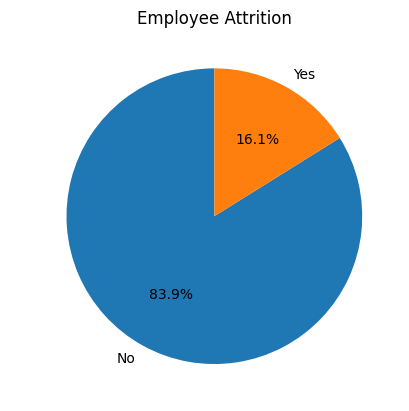

In [13]:
# Pie Chart
df_full["Attrition"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Employee Attrition")
plt.ylabel(" ")
plt.show()

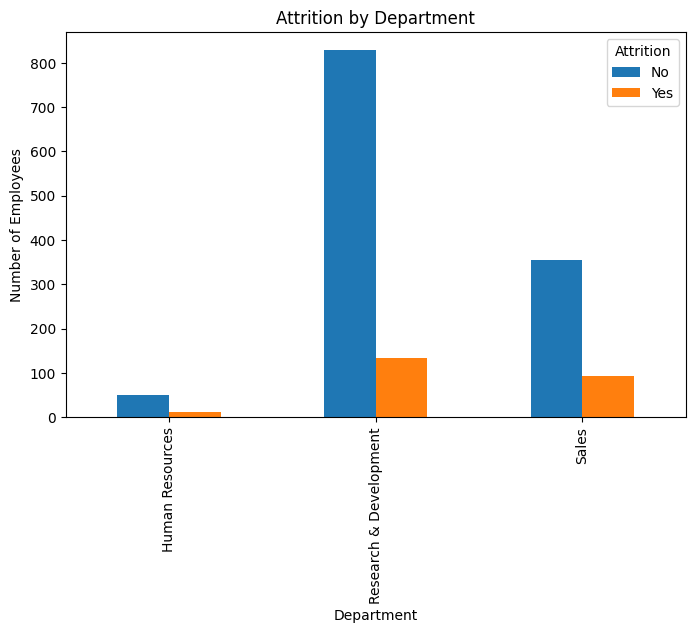

In [14]:
# Bar Graph
department= df_full.groupby("Department")["Attrition"].value_counts().unstack()
department.plot(kind="bar",figsize=(8,5))
plt.title("Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()